In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [12]:
os.makedirs('graphs', exist_ok=True)

# Swarms

In [13]:
# Load all 5 house datasets
dfs = []
for i in range(1, 6):
    df = pd.read_csv(f'mesh_comparison_results/comparison_swarm_house{i}.csv')
    df['house'] = i
    dfs.append(df)

# Combine all dataframes
combined_df = pd.concat(dfs, ignore_index=True)

print("Combined DataFrame shape:", combined_df.shape)
print("\nFirst few rows:")
print(combined_df.head())

# Calculate average metrics grouped by drones and interval
avg_by_drones_interval = combined_df.groupby(['drones', 'interval']).agg({
    'mesh_visibility': ['mean', 'std'],
    'convergence_time': ['mean', 'std'],
    'num_points': 'mean',
    'chamfer_distance': ['mean', 'std']
}).reset_index()

# Flatten column names
avg_by_drones_interval.columns = ['_'.join(col).strip('_') for col in avg_by_drones_interval.columns.values]

print("\n\nAveraged DataFrame by drones and interval:")
print(avg_by_drones_interval)

# For convergence time by drones (independent of interval since it's the same)
avg_convergence_by_drones = combined_df.groupby('drones').agg({
    'convergence_time': ['mean', 'std']
}).reset_index()
avg_convergence_by_drones.columns = ['drones', 'convergence_time_mean', 'convergence_time_std']

print("\n\nAveraged convergence time by drones:")
print(avg_convergence_by_drones)

Combined DataFrame shape: (225, 12)

First few rows:
                                   filename  drones  interval  \
0  swarm_raw_1_drones_1_interval_61.81s.ply       1         1   
1  swarm_raw_1_drones_2_interval_61.81s.ply       1         2   
2  swarm_raw_1_drones_3_interval_61.81s.ply       1         3   
3  swarm_raw_1_drones_4_interval_61.81s.ply       1         4   
4  swarm_raw_1_drones_5_interval_61.81s.ply       1         5   

   convergence_time  num_points  mesh_visibility  mesh_overlap  \
0             61.81      773149           77.108     77.862727   
1             61.81      777727           76.432     77.770162   
2             61.81      788562           76.428     77.991744   
3             61.81      769402           73.958     77.726929   
4             61.81      773686           76.863     77.811024   

   chamfer_distance  mean_distance_to_gt  threshold  adjusted_threshold  house  
0          0.008009             0.003344        0.1             0.00456      1

## Mesh Visibility across intervals

- X-axis: Camera Sampling Interval (s)
- Y-axis: Mesh Visibility
- Lines: No. of Drones
- Error Bars: Stdev Across 5 Houses


Graph 1 saved as 'swarm_visibility_vs_interval.png'


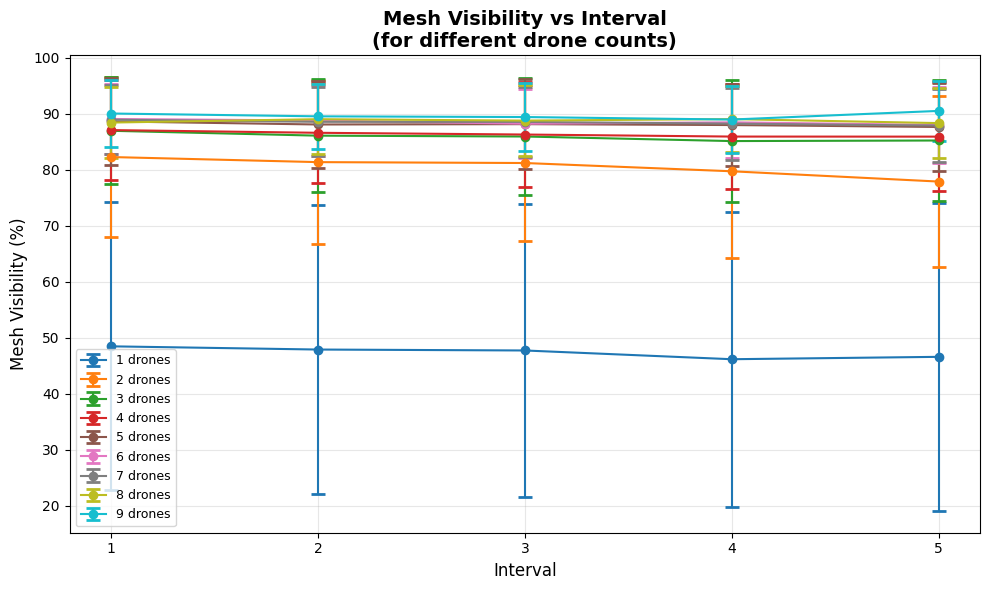

In [14]:
# Graph 1: Mesh visibility across intervals (lines for each drone count)
plt.figure(figsize=(10, 6))
drone_counts = sorted(combined_df['drones'].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(drone_counts)))

for idx, drone_count in enumerate(drone_counts):
    data = avg_by_drones_interval[avg_by_drones_interval['drones'] == drone_count]
    plt.errorbar(data['interval'], data['mesh_visibility_mean'], 
                 yerr=data['mesh_visibility_std'],
                 marker='o', label=f'{drone_count} drones', 
                 color=colors[idx], capsize=5, capthick=2)

plt.xlabel('Interval', fontsize=12)
plt.ylabel('Mesh Visibility (%)', fontsize=12)
plt.title('Mesh Visibility vs Interval\n(for different drone counts)', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.xticks(sorted(combined_df['interval'].unique()))
plt.tight_layout()
plt.savefig('graphs/swarm_visibility_vs_interval.png', dpi=300, bbox_inches='tight')
print("\nGraph 1 saved as 'swarm_visibility_vs_interval.png'")
plt.show()

## Mesh Visibility across Drones

- X-axis: Drones
- Y-axis: Mesh Visibility
- Lines: Camera Sampling Interval
- Error Bars: Stdev Across 5 Houses

Graph 2 saved as 'swarm_visibility_vs_drones.png'


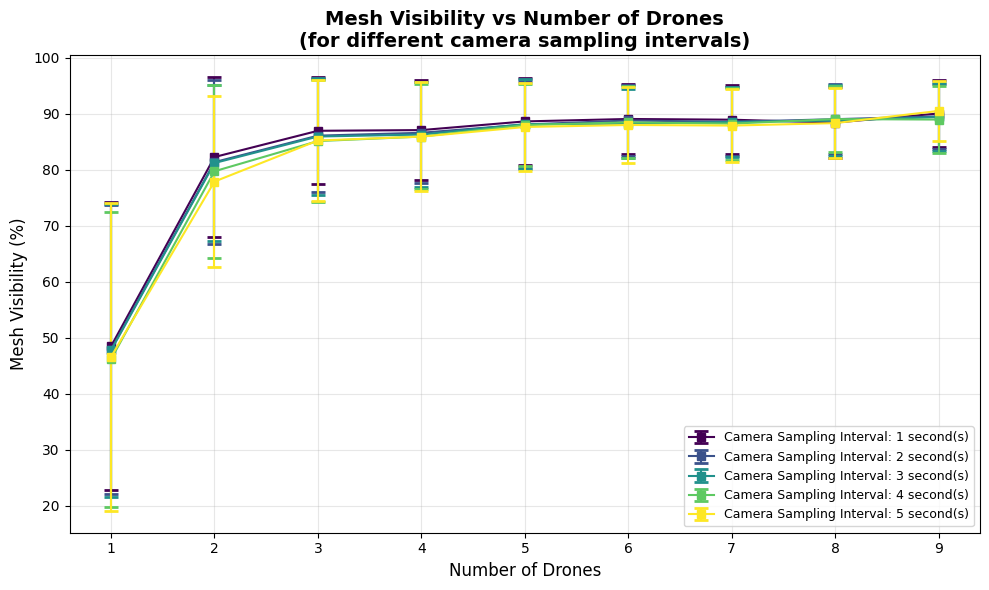

In [39]:
# Graph 2: Mesh visibility across drones (lines for each interval)
plt.figure(figsize=(10, 6))
intervals = sorted(combined_df['interval'].unique())
colors2 = plt.cm.viridis(np.linspace(0, 1, len(intervals)))

for idx, interval in enumerate(intervals):
    data = avg_by_drones_interval[avg_by_drones_interval['interval'] == interval]
    plt.errorbar(data['drones'], data['mesh_visibility_mean'], 
                 yerr=data['mesh_visibility_std'],
                 marker='s', label=f'Camera Sampling Interval: {interval} second(s)', 
                 color=colors2[idx], capsize=5, capthick=2)

plt.xlabel('Number of Drones', fontsize=12)
plt.ylabel('Mesh Visibility (%)', fontsize=12)
plt.title('Mesh Visibility vs Number of Drones\n(for different camera sampling intervals)', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.xticks(drone_counts)
plt.tight_layout()
plt.savefig('graphs/swarm_visibility_vs_drones.png', dpi=300, bbox_inches='tight')
print("Graph 2 saved as 'swarm_visibility_vs_drones.png'")
plt.show()

# print("   - X-axis: Number of drones (1, 2, 3, 4, 5, 6, 7, 8, 9)")
# print("   - Y-axis: Mesh visibility (in %)")
# print("   - Each LINE: Represents a different interval (1, 2, 3, 4, 5 seconds)")
# print("   - Each POINT on a line: The AVERAGE mesh visibility across 5 houses")
# print("   - Each ERROR BAR: The STANDARD DEVIATION across those 5 houses\n")


## Mesh Visibility across Drones

- X-axis: Drones
- Y-axis: Mesh Visibility
- Lines: Houses, Averaged by Camera Sampling Interval

Graph saved as 'swarm_visibility_by_house.png'


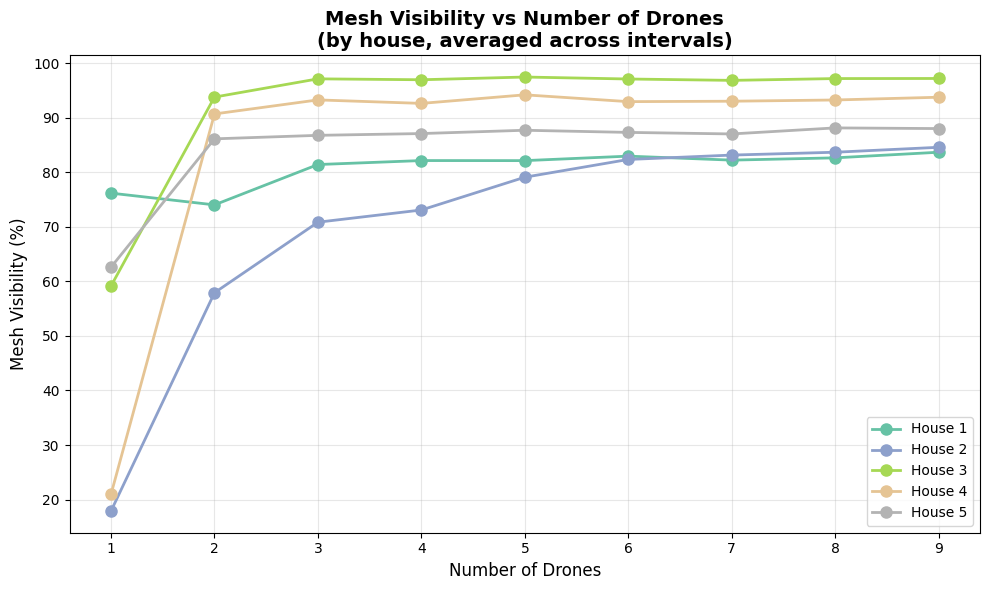

In [24]:
# Graph: Mesh visibility across drones (separate line for each house, intervals averaged)
plt.figure(figsize=(10, 6))

# Calculate average across intervals for each house and drone count
avg_by_house_drones = combined_df.groupby(['house', 'drones']).agg({
    'mesh_visibility': 'mean',
    'convergence_time': 'mean'
}).reset_index()

houses = sorted(combined_df['house'].unique())
colors_house = plt.cm.Set2(np.linspace(0, 1, len(houses)))

for idx, house in enumerate(houses):
    data = avg_by_house_drones[avg_by_house_drones['house'] == house]
    plt.plot(data['drones'], data['mesh_visibility'], 
             marker='o', label=f'House {house}', 
             color=colors_house[idx], linewidth=2, markersize=8)

plt.xlabel('Number of Drones', fontsize=12)
plt.ylabel('Mesh Visibility (%)', fontsize=12)
plt.title('Mesh Visibility vs Number of Drones\n(by house, averaged across intervals)', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(drone_counts)
plt.tight_layout()
plt.savefig('graphs/swarm_visibility_by_house.png', dpi=300, bbox_inches='tight')
print("Graph saved as 'swarm_visibility_by_house.png'")
plt.show()

# Show the data
# print("\nMesh visibility by house (averaged across all intervals):")
# pivot_display = avg_by_house_drones.pivot(index='drones', columns='house', values='mesh_visibility')
# print(pivot_display.round(2))

## Mesh Visibility across Drones

- X-axis: No. of Drones
- Y-axis: Time to Reach Migration Point (Convergence Point)
- Error Bars: Stdev Across 5 Houses

Graph 3 saved as 'swarm_convergence_time.png'


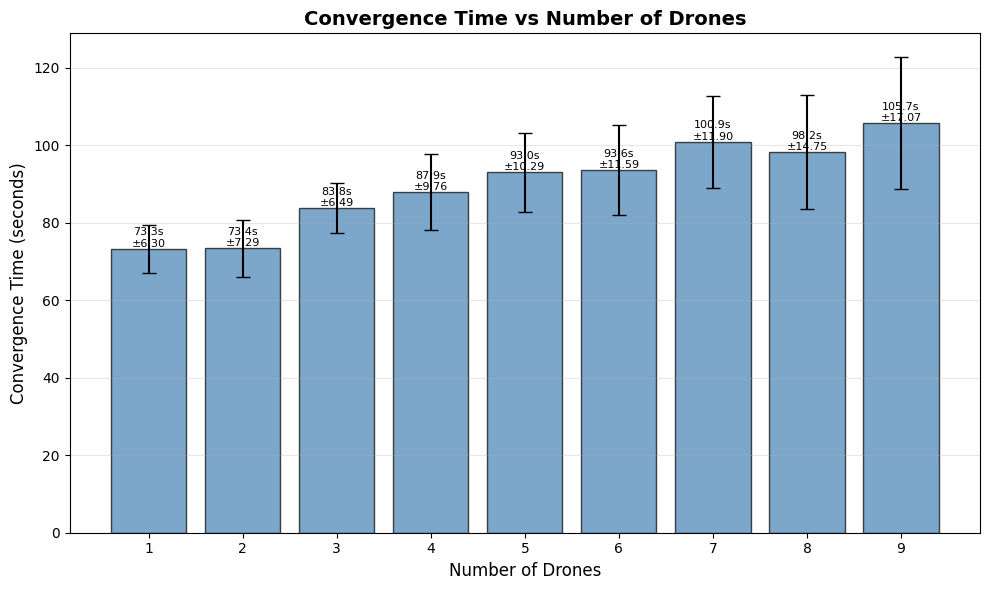

In [23]:
# Graph 3: Convergence time by drone count (bar chart)
plt.figure(figsize=(10, 6))
bars = plt.bar(avg_convergence_by_drones['drones'], 
               avg_convergence_by_drones['convergence_time_mean'],
               yerr=avg_convergence_by_drones['convergence_time_std'],
               capsize=5, alpha=0.7, color='steelblue', edgecolor='black')

plt.xlabel('Number of Drones', fontsize=12)
plt.ylabel('Convergence Time (seconds)', fontsize=12)
plt.title('Convergence Time vs Number of Drones', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(drone_counts)

# Add value labels on bars
for bar, mean_val, std_val in zip(bars, 
                                    avg_convergence_by_drones['convergence_time_mean'],
                                    avg_convergence_by_drones['convergence_time_std']):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{mean_val:.1f}s\n±{std_val:.2f}',
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('graphs/swarm_convergence_time.png', dpi=300, bbox_inches='tight')
print("Graph 3 saved as 'swarm_convergence_time.png'")
plt.show()

# Display the averaged dataframe
# avg_by_drones_interval

In [20]:
# Print some summary statistics
print("\n\n=== SUMMARY STATISTICS ===")
print(f"\nTotal experiments analyzed: {len(combined_df)}")
print(f"Number of houses: {combined_df['house'].nunique()}")
print(f"Drone counts tested: {np.max(combined_df['drones'].unique())}")
print(f"Intervals tested: {np.max(combined_df['interval'].unique())}")

print("\n\nMesh Visibility Summary:")
print(f"Overall mean: {combined_df['mesh_visibility'].mean():.2f}%")
print(f"Overall std: {combined_df['mesh_visibility'].std():.2f}%")
print(f"Best result: {combined_df['mesh_visibility'].max():.2f}%")
print(f"Worst result: {combined_df['mesh_visibility'].min():.2f}%")




=== SUMMARY STATISTICS ===

Total experiments analyzed: 225
Number of houses: 5
Drone counts tested: 9
Intervals tested: 5


Mesh Visibility Summary:
Overall mean: 82.60%
Overall std: 16.76%
Best result: 98.03%
Worst result: 13.83%


# Other plots (that could be relevant)

In [25]:
# Calculate averages for all metrics
avg_all_metrics = combined_df.groupby(['drones', 'interval']).agg({
    'mesh_visibility': ['mean', 'std'],
    'convergence_time': ['mean', 'std'],
    'num_points': ['mean', 'std'],
    'chamfer_distance': ['mean', 'std'],
    'mesh_overlap': ['mean', 'std']
}).reset_index()

# Flatten column names
avg_all_metrics.columns = ['_'.join(col).strip('_') for col in avg_all_metrics.columns.values]

# Calculate efficiency metric: visibility per second
combined_df['visibility_per_second'] = combined_df['mesh_visibility'] / combined_df['convergence_time']

avg_efficiency = combined_df.groupby(['drones', 'interval']).agg({
    'visibility_per_second': ['mean', 'std']
}).reset_index()
avg_efficiency.columns = ['drones', 'interval', 'visibility_per_second_mean', 'visibility_per_second_std']

Plot 1 saved as 'swarm_chamfer_vs_drones.png'


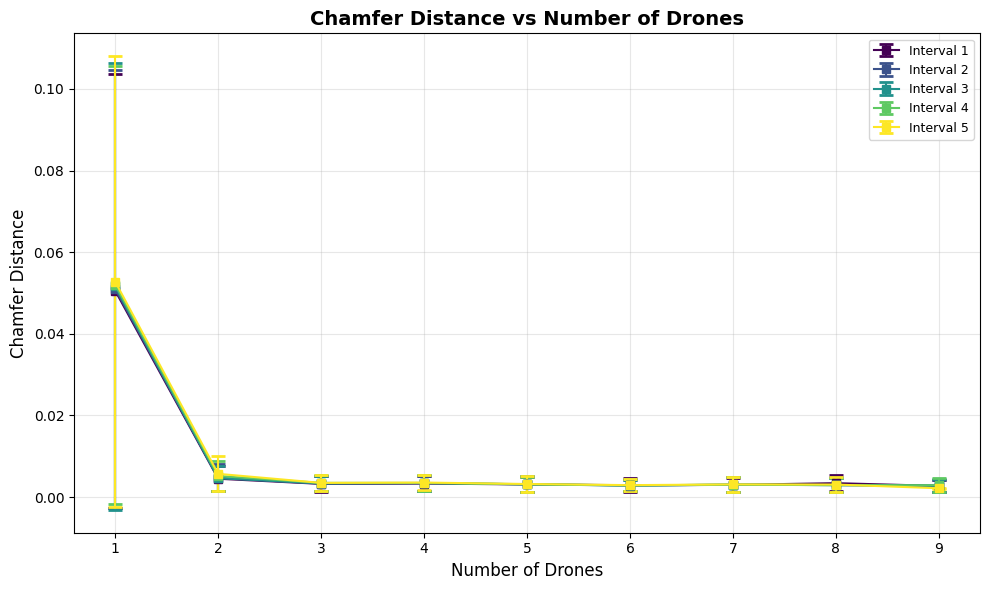

In [27]:
# 1) Chamfer Distance vs Drones
plt.figure(figsize=(10, 6))
intervals = sorted(combined_df['interval'].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(intervals)))

for idx, interval in enumerate(intervals):
    data = avg_all_metrics[avg_all_metrics['interval'] == interval]
    plt.errorbar(data['drones'], data['chamfer_distance_mean'], 
                 yerr=data['chamfer_distance_std'],
                 marker='s', label=f'Interval {interval}', 
                 color=colors[idx], capsize=5, capthick=2)

plt.xlabel('Number of Drones', fontsize=12)
plt.ylabel('Chamfer Distance', fontsize=12)
plt.title('Chamfer Distance vs Number of Drones', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.xticks(drone_counts)
plt.tight_layout()
plt.savefig('graphs/swarm_chamfer_vs_drones.png', dpi=300, bbox_inches='tight')
print("Plot 1 saved as 'swarm_chamfer_vs_drones.png'")
plt.show()

Plot 2 saved as 'swarm_overlap_vs_drones.png'


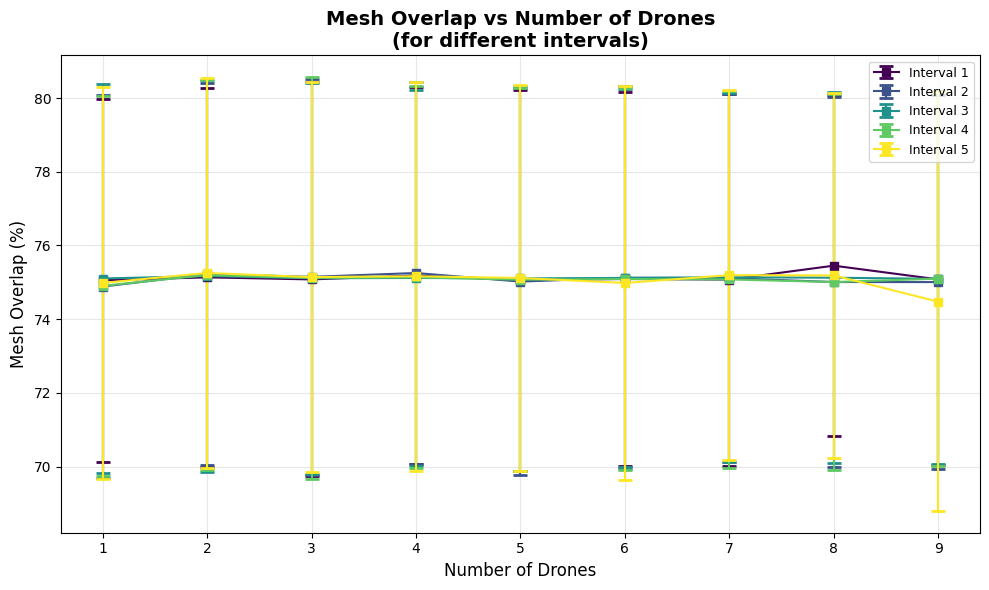

In [28]:
# 2) Mesh Overlap vs Drones
plt.figure(figsize=(10, 6))

for idx, interval in enumerate(intervals):
    data = avg_all_metrics[avg_all_metrics['interval'] == interval]
    plt.errorbar(data['drones'], data['mesh_overlap_mean'], 
                 yerr=data['mesh_overlap_std'],
                 marker='s', label=f'Interval {interval}', 
                 color=colors[idx], capsize=5, capthick=2)

plt.xlabel('Number of Drones', fontsize=12)
plt.ylabel('Mesh Overlap (%)', fontsize=12)
plt.title('Mesh Overlap vs Number of Drones\n(for different intervals)', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.xticks(drone_counts)
plt.tight_layout()
plt.savefig('graphs/swarm_overlap_vs_drones.png', dpi=300, bbox_inches='tight')
print("Plot 2 saved as 'swarm_overlap_vs_drones.png'")
plt.show()

Plot 3 saved as 'swarm_points_vs_drones.png'


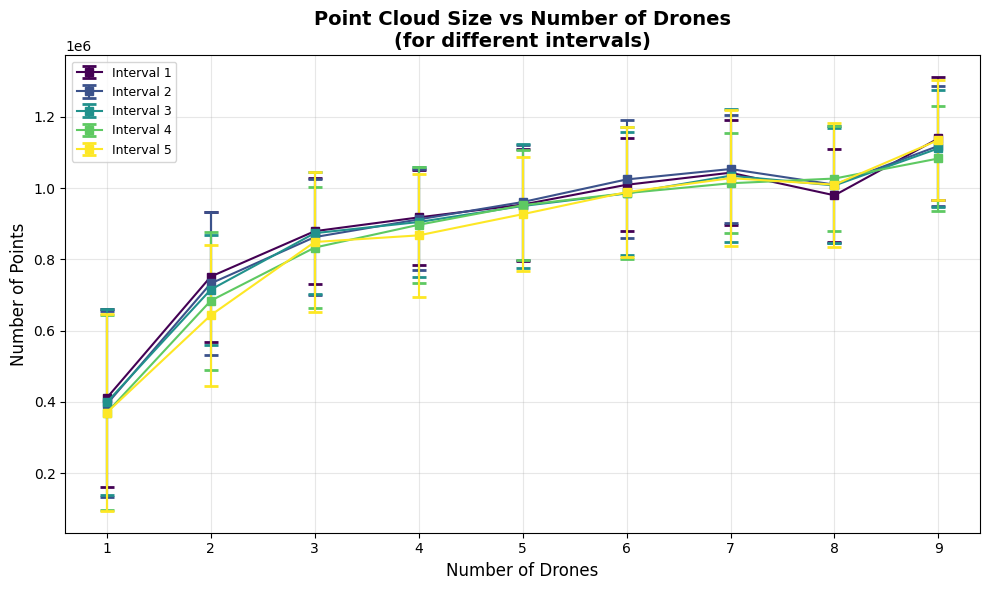

In [29]:
# 3) Number of Points vs Drones
plt.figure(figsize=(10, 6))

for idx, interval in enumerate(intervals):
    data = avg_all_metrics[avg_all_metrics['interval'] == interval]
    plt.errorbar(data['drones'], data['num_points_mean'], 
                 yerr=data['num_points_std'],
                 marker='s', label=f'Interval {interval}', 
                 color=colors[idx], capsize=5, capthick=2)

plt.xlabel('Number of Drones', fontsize=12)
plt.ylabel('Number of Points', fontsize=12)
plt.title('Point Cloud Size vs Number of Drones\n(for different intervals)', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.xticks(drone_counts)
plt.tight_layout()
plt.savefig('graphs/swarm_points_vs_drones.png', dpi=300, bbox_inches='tight')
print("Plot 3 saved as 'swarm_points_vs_drones.png'")
plt.show()

Plot 4 saved as 'swarm_efficiency_vs_drones.png'


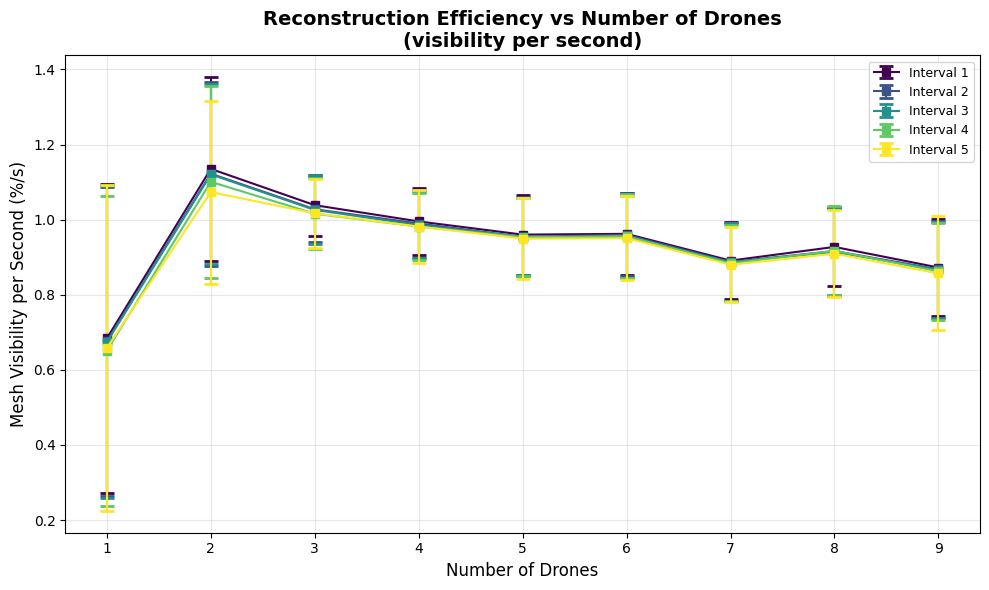

In [30]:
# 4) Mesh Visibility per Second (Efficiency)
plt.figure(figsize=(10, 6))

for idx, interval in enumerate(intervals):
    data = avg_efficiency[avg_efficiency['interval'] == interval]
    plt.errorbar(data['drones'], data['visibility_per_second_mean'], 
                 yerr=data['visibility_per_second_std'],
                 marker='s', label=f'Interval {interval}', 
                 color=colors[idx], capsize=5, capthick=2)

plt.xlabel('Number of Drones', fontsize=12)
plt.ylabel('Mesh Visibility per Second (%/s)', fontsize=12)
plt.title('Reconstruction Efficiency vs Number of Drones\n(visibility per second)', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.xticks(drone_counts)
plt.tight_layout()
plt.savefig('graphs/swarm_efficiency_vs_drones.png', dpi=300, bbox_inches='tight')
print("Plot 4 saved as 'swarm_efficiency_vs_drones.png'")
plt.show()

Plot 5 saved as 'swarm_3d_surface.png'


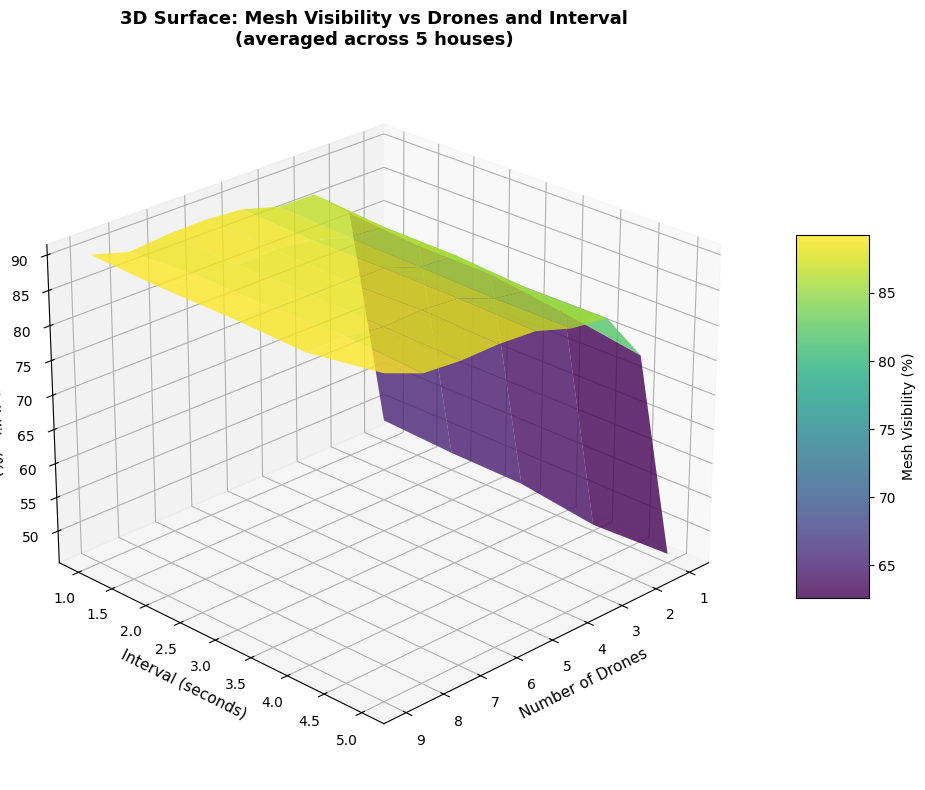

In [31]:
# 5) 3D Surface Plot - Drones, Intervals, Visibility
from mpl_toolkits.mplot3d import Axes3D

# Get averaged data (no std needed for 3D surface)
avg_for_3d = combined_df.groupby(['drones', 'interval'])['mesh_visibility'].mean().reset_index()

# Create meshgrid
drones_unique = sorted(avg_for_3d['drones'].unique())
intervals_unique = sorted(avg_for_3d['interval'].unique())

# Pivot to create 2D array for surface
visibility_pivot = avg_for_3d.pivot(index='interval', columns='drones', values='mesh_visibility')

X, Y = np.meshgrid(drones_unique, intervals_unique)
Z = visibility_pivot.values

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, edgecolor='none')

ax.set_xlabel('Number of Drones', fontsize=11)
ax.set_ylabel('Interval (seconds)', fontsize=11)
ax.set_zlabel('Mesh Visibility (%)', fontsize=11)
ax.set_title('3D Surface: Mesh Visibility vs Drones and Interval\n(averaged across 5 houses)', 
             fontsize=13, fontweight='bold')

fig.colorbar(surf, shrink=0.5, aspect=5, label='Mesh Visibility (%)')
ax.view_init(elev=25, azim=45)

plt.tight_layout()
plt.savefig('graphs/swarm_3d_surface.png', dpi=300, bbox_inches='tight')
print("Plot 5 saved as 'swarm_3d_surface.png'")
plt.show()

Plot 6 saved as 'swarm_diminishing_returns.png'


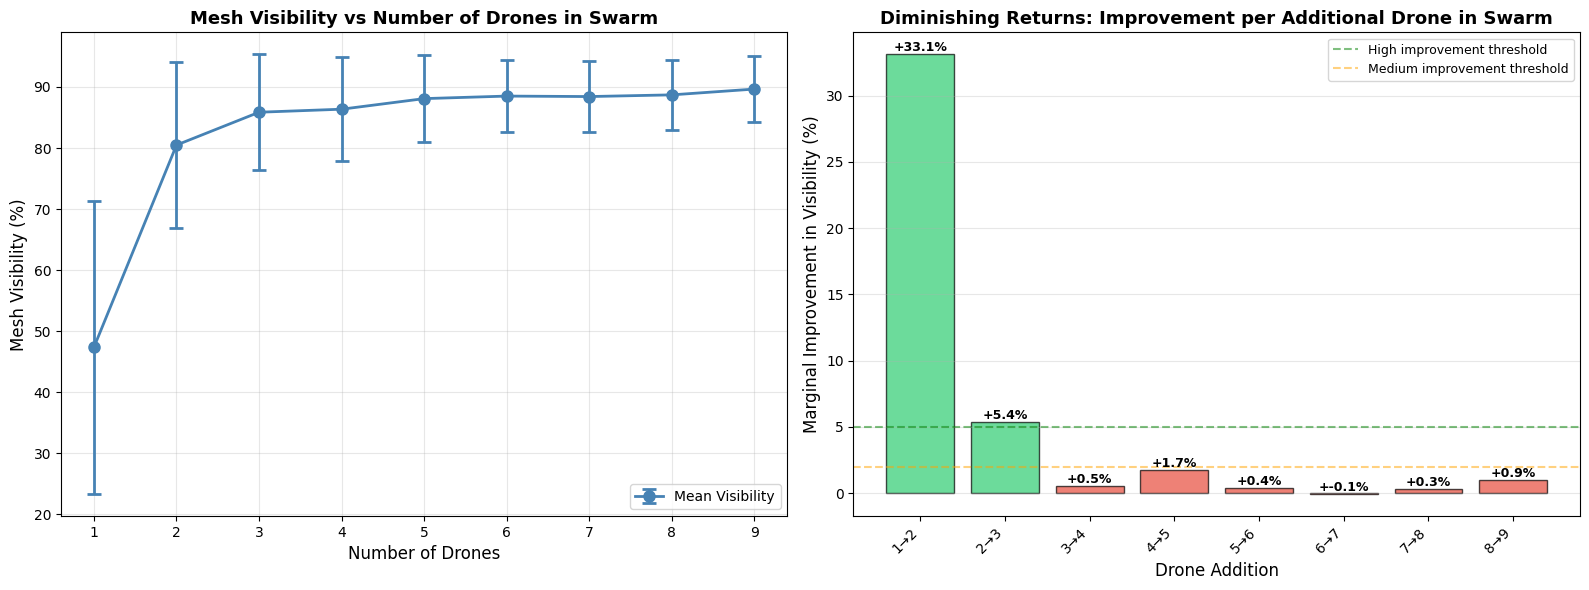


=== DIMINISHING RETURNS ANALYSIS ===

Marginal improvements:
  1→2: +33.13%
  2→3: +5.38%
  3→4: +0.50%
  4→5: +1.73%
  5→6: +0.41%
  6→7: +-0.08%
  7→8: +0.28%
  8→9: +0.95%

✓ Optimal drone count: 3 drones
  (improvements drop below 2.0% after this point)


In [35]:
# 6) Diminishing Returns Plot - Marginal Improvement per Additional Drone
# Average across all intervals and houses
avg_by_drones_only = combined_df.groupby('drones').agg({
    'mesh_visibility': ['mean', 'std']
}).reset_index()
avg_by_drones_only.columns = ['drones', 'visibility_mean', 'visibility_std']

# Calculate marginal improvement (difference between consecutive drone counts)
marginal_improvement = []
drone_transitions = []

for i in range(len(avg_by_drones_only) - 1):
    improvement = (avg_by_drones_only.iloc[i+1]['visibility_mean'] - 
                   avg_by_drones_only.iloc[i]['visibility_mean'])
    marginal_improvement.append(improvement)
    drone_transitions.append(f"{int(avg_by_drones_only.iloc[i]['drones'])}→{int(avg_by_drones_only.iloc[i+1]['drones'])}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Absolute visibility with error bars
ax1.errorbar(avg_by_drones_only['drones'], avg_by_drones_only['visibility_mean'],
             yerr=avg_by_drones_only['visibility_std'],
             marker='o', color='steelblue', linewidth=2, markersize=8,
             capsize=5, capthick=2, label='Mean Visibility')

ax1.set_xlabel('Number of Drones', fontsize=12)
ax1.set_ylabel('Mesh Visibility (%)', fontsize=12)
ax1.set_title('Mesh Visibility vs Number of Drones in Swarm', 
              fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(drone_counts)
ax1.legend()

# Right plot: Marginal improvement
colors_bar = ['#2ecc71' if x > 5 else '#f39c12' if x > 2 else '#e74c3c' 
              for x in marginal_improvement]
bars = ax2.bar(range(len(marginal_improvement)), marginal_improvement, 
               color=colors_bar, alpha=0.7, edgecolor='black')

ax2.set_xlabel('Drone Addition', fontsize=12)
ax2.set_ylabel('Marginal Improvement in Visibility (%)', fontsize=12)
ax2.set_title('Diminishing Returns: Improvement per Additional Drone in Swarm', 
              fontsize=13, fontweight='bold')
ax2.set_xticks(range(len(drone_transitions)))
ax2.set_xticklabels(drone_transitions, rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(y=5, color='green', linestyle='--', alpha=0.5, label='High improvement threshold')
ax2.axhline(y=2, color='orange', linestyle='--', alpha=0.5, label='Medium improvement threshold')
ax2.legend(fontsize=9)

# Add value labels on bars
for bar, improvement in zip(bars, marginal_improvement):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'+{improvement:.1f}%',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('graphs/swarm_diminishing_returns.png', dpi=300, bbox_inches='tight')
print("Plot 6 saved as 'swarm_diminishing_returns.png'")
plt.show()

# Print optimal drone count analysis
print("\n=== DIMINISHING RETURNS ANALYSIS ===")
print("\nMarginal improvements:")
for transition, improvement in zip(drone_transitions, marginal_improvement):
    print(f"  {transition}: +{improvement:.2f}%")

# Find where improvement drops below threshold
threshold = 2.0  # You can adjust this
optimal_idx = next((i for i, imp in enumerate(marginal_improvement) if imp < threshold), len(marginal_improvement))
if optimal_idx < len(drone_transitions):
    print(f"\n✓ Optimal drone count: {optimal_idx + 1} drones")
    print(f"  (improvements drop below {threshold}% after this point)")
else:
    print(f"\n✓ All improvements remain above {threshold}% threshold")

Plot 6 saved as 'swarm_diminishing_returns.png'


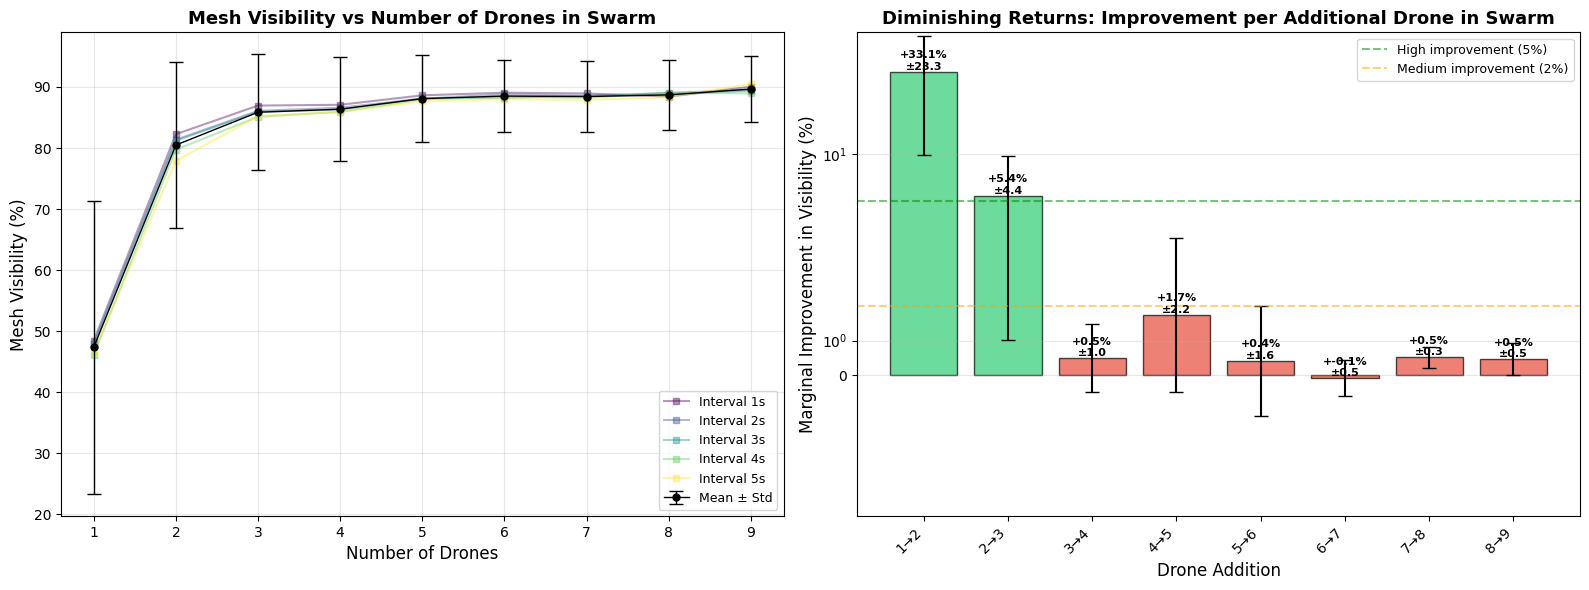


=== DIMINISHING RETURNS ANALYSIS ===

Marginal improvements (mean ± std across 5 houses):
  1→2: +33.13% ± 23.34%
  2→3: +5.38% ± 4.37%
  3→4: +0.50% ± 0.98%
  4→5: +1.73% ± 2.20%
  5→6: +0.41% ± 1.56%
  6→7: +-0.08% ± 0.51%
  7→8: +0.52% ± 0.31%
  8→9: +0.47% ± 0.46%

✓ Optimal drone count: 3 drones
  (improvements drop below 2.0% after this point)


In [54]:
# 6) Enhanced Diminishing Returns Plot
# Average across all intervals and houses
avg_by_drones_only = combined_df.groupby('drones').agg({
    'mesh_visibility': ['mean', 'std']
}).reset_index()
avg_by_drones_only.columns = ['drones', 'visibility_mean', 'visibility_std']

# Calculate marginal improvement for each house
marginal_by_house = []
for house in sorted(combined_df['house'].unique()):
    house_data = combined_df[combined_df['house'] == house].groupby('drones')['mesh_visibility'].mean().reset_index()
    improvements = []
    for i in range(len(house_data) - 1):
        improvement = house_data.iloc[i+1]['mesh_visibility'] - house_data.iloc[i]['mesh_visibility']
        improvements.append(improvement)
    marginal_by_house.append(improvements)

marginal_by_house = np.array(marginal_by_house)
marginal_mean = np.mean(marginal_by_house, axis=0)
marginal_std = np.std(marginal_by_house, axis=0)

drone_transitions = []
for i in range(len(avg_by_drones_only) - 1):
    drone_transitions.append(f"{int(avg_by_drones_only.iloc[i]['drones'])}→{int(avg_by_drones_only.iloc[i+1]['drones'])}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Show individual interval lines + mean with error bars
intervals = sorted(combined_df['interval'].unique())
colors_interval = plt.cm.viridis(np.linspace(0, 1, len(intervals)))

# Plot individual intervals first (lighter lines)
for idx, interval in enumerate(intervals):
    interval_data = combined_df[combined_df['interval'] == interval].groupby('drones')['mesh_visibility'].mean().reset_index()
    ax1.plot(interval_data['drones'], interval_data['mesh_visibility'], 
             marker='s', alpha=0.4, linewidth=1.5, markersize=5,
             color=colors_interval[idx], label=f'Interval {interval}s')

# Plot mean with error bars on top (bold)
ax1.errorbar(avg_by_drones_only['drones'], avg_by_drones_only['visibility_mean'],
             yerr=avg_by_drones_only['visibility_std'],
             marker='o', color='black', linewidth=1, markersize=5,
             capsize=5, capthick=1, label='Mean ± Std', zorder=10)

ax1.set_xlabel('Number of Drones', fontsize=12)
ax1.set_ylabel('Mesh Visibility (%)', fontsize=12)
ax1.set_title('Mesh Visibility vs Number of Drones in Swarm', 
              fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(drone_counts)
ax1.legend(loc='lower right', fontsize=9)

# Right plot: Regular scale starting from 0
colors_bar = ['#2ecc71' if x > 5 else '#f39c12' if x > 2 else '#e74c3c' 
              for x in marginal_mean]

bars = ax2.bar(range(len(marginal_mean)), marginal_mean, 
               yerr=marginal_std,
               color=colors_bar, alpha=0.7, edgecolor='black',
               capsize=5)

ax2.set_xlabel('Drone Addition', fontsize=12)
ax2.set_ylabel('Marginal Improvement in Visibility (%)', fontsize=12)
ax2.set_title('Diminishing Returns: Improvement per Additional Drone in Swarm', 
              fontsize=13, fontweight='bold')
ax2.set_xticks(range(len(drone_transitions)))
ax2.set_xticklabels(drone_transitions, rotation=45, ha='right')

# Set y-axis to start from 0
ax2.set_yscale('symlog', linthresh=5)  # 
# ax2.set_ylim(bottom=0)
ax2.grid(True, alpha=0.3, axis='y')

# Add horizontal reference lines
ax2.axhline(y=5, color='green', linestyle='--', alpha=0.5, linewidth=1.5, label='High improvement (5%)')
ax2.axhline(y=2, color='orange', linestyle='--', alpha=0.5, linewidth=1.5, label='Medium improvement (2%)')
ax2.legend(fontsize=9)

# Add value labels on bars
for bar, improvement, std in zip(bars, marginal_mean, marginal_std):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'+{improvement:.1f}%\n±{std:.1f}',
             ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('graphs/swarm_diminishing_returns.png', dpi=300, bbox_inches='tight')
print("Plot 6 saved as 'swarm_diminishing_returns.png'")
plt.show()

# Print analysis
print("\n=== DIMINISHING RETURNS ANALYSIS ===")
print("\nMarginal improvements (mean ± std across 5 houses):")
for transition, improvement, std in zip(drone_transitions, marginal_mean, marginal_std):
    print(f"  {transition}: +{improvement:.2f}% ± {std:.2f}%")

threshold = 2.0
optimal_idx = next((i for i, imp in enumerate(marginal_mean) if imp < threshold), len(marginal_mean))
if optimal_idx < len(drone_transitions):
    print(f"\n✓ Optimal drone count: {optimal_idx + 1} drones")
    print(f"  (improvements drop below {threshold}% after this point)")
else:
    print(f"\n✓ All improvements remain above {threshold}% threshold")